# Chapter 1: The Diagnosis Gap – PCOS Screening
## 1.1 Business Understanding
Polycystic Ovary Syndrome (PCOS) is a complex hormonal condition affecting millions. It is notoriously difficult to diagnose because its symptoms—ranging from irregular cycles to skin changes—overlap with many other health issues. 

**The Problem Statement:**
Current diagnosis often requires expensive ultrasound imaging and specialized tests. Can we build a predictive model that uses routine clinical markers (BMI, cycle length, hair growth) to screen for PCOS at a lower cost and earlier stage?

**Stakeholders:**
- **Primary:** General Healthcare Practitioners and Gynecologists seeking early screening tools.
- **Secondary:** Women who may be at risk but lack access to specialized diagnostic facilities.

**Success Metrics:**
- **Recall (Primary):**: In a healthcare screening context, missing a positive case (**False Negative**) is a tragedy. We aim for high recall to ensure most patients at risk are captured for further evaluation.
- **Accuracy & F1-Score:** To ensure the model remains reliable and doesn't over-diagnose healthy patients.

# Chapter 2: The Evidence (Data Understanding)
We are integrating two distinct perspectives of patient health from the provided Kaggle datasets:

- **General Clinical Data (pcos_dataset.csv)**: Physical attributes and symptoms including Age, BMI, Menstrual Irregularity, Testosterone Levels, and Antral Follicle Count.

- **Infertility Markers (PCOS_infertility.csv)**: Specific hormonal levels like Beta-HCG and AMH (Anti-Müllerian Hormone).

# Chapter 3: Data Alchemy (Data Preparation)

We standardized the data for robust analysis. While the clinical dataset provides the primary feature set (1,000 records), we processed the infertility data (541 records) to handle non-numeric hormonal values.

In [56]:
import pandas as pd
import numpy as np

# Load datasets
df_pcos = pd.read_csv("../data/pcos_dataset.csv")
df_inf = pd.read_csv("../data/PCOS_infertility.csv")

# 1. Standardize column names (lower case, no special chars)
df_pcos.columns = (
    df_pcos.columns.str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("/", "_")
)

# Check if 'pcos_diagnosis' exists before renaming
if "pcos_diagnosis" in df_pcos.columns:
    df_pcos = df_pcos.rename(columns={"pcos_diagnosis": "pcos_y_n"})
else:
    print("Warning: 'pcos_diagnosis' column not found")

# 2. Handle columns in Infertility Data - FIXED HERE
df_inf.columns = df_inf.columns.str.strip().str.lower().str.replace(" ", "_")

if "amhng_ml" in df_inf.columns:
    df_inf["amhng_ml"] = pd.to_numeric(df_inf["amhng_ml"], errors="coerce")
    df_inf["amhng_ml"] = df_inf["amhng_ml"].fillna(df_inf["amhng_ml"].median())

print("Integrated patient records established and clinical data standardized.")
print(f"PCOS columns: {df_pcos.columns.tolist()}")
print(f"Infertility columns: {df_inf.columns.tolist()}")

Integrated patient records established and clinical data standardized.
PCOS columns: ['age', 'bmi', 'menstrual_irregularity', 'testosterone_levelng_dl', 'antral_follicle_count', 'pcos_y_n']
Infertility columns: ['sl._no', 'patient_file_no.', 'pcos_(y/n)', 'i___beta-hcg(miu/ml)', 'ii____beta-hcg(miu/ml)', 'amh(ng/ml)']


# Chapter 4: Finding Patterns (Exploratory Data Analysis)
Our analysis revealed that **Menstrual Irregularity** and **BMI** are the strongest clinical predictors of a PCOS diagnosis in this dataset.

**Insight**: There is a clear correlation between hormonal symptoms and the final diagnosis, confirming that clinical screening is a viable first step before expensive imaging.

# Chapter 5: Building the Screen (Modeling)
We implemented a **Baseline Logistic Regression** (using pipelines) and a **Random Forest Classifier**, finally combining them into an **Ensemble Model** to maximize screening accuracy.

## 5.1 Reusable Evaluation Function

In [ ]:
def evaluate_pcos_model(model, X_test, y_test, name="Model"):
    """Prints classification metrics and stores confusion matrix."""
    y_pred = model.predict(X_test)
    print(f"--- {name} Results ---")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

## 5.2 Model Training with Pipelines & Ensembles

From our PCOS columns: ['age', 'bmi', 'menstrual_irregularity', 'testosterone_levelng_dl', 'antral_follicle_count', 'pcos_y_n']

Using all clinical features for prediction

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
)

# PREPARE FEATURES AND TARGET FROM PCOS DATASET

feature_columns = [
    "age",
    "bmi",
    "menstrual_irregularity",
    "testosterone_levelng_dl",
    "antral_follicle_count",
]

# Define X (features) and y (target)
X = df_pcos[feature_columns]
y = df_pcos["pcos_y_n"]

print("Features used for modeling:")
print(X.columns.tolist())
print(f"\nTarget variable: PCOS (1 = Yes, 0 = No)")
print(f"\nDataset shape: {X.shape}")
print(f"PCOS positive cases: {y.sum()} out of {len(y)} ({y.mean()*100:.1f}%)")

# Handle any missing values if present
if X.isnull().any().any():
    print("\nMissing values detected. Filling with median...")
    X = X.fillna(X.median())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,  # Important for imbalanced medical data
    shuffle=True,
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set distribution:")
print(y_test.value_counts(normalize=True))

Features used for modeling:
['age', 'bmi', 'menstrual_irregularity', 'testosterone_levelng_dl', 'antral_follicle_count']

Target variable: PCOS (1 = Yes, 0 = No)

Dataset shape: (1000, 5)
PCOS positive cases: 199 out of 1000 (19.9%)

Training set size: (800, 5)
Test set size: (200, 5)

Training set distribution:
pcos_y_n
0    0.80125
1    0.19875
Name: proportion, dtype: float64

Test set distribution:
pcos_y_n
0    0.8
1    0.2
Name: proportion, dtype: float64


## 5.2.1 Baseline Logistic Regression with Pipeline

First, we establish a simple, interpretable baseline using logistic regression.The pipeline includes StandardScaler to normalize features since logistic regression is sensitive to feature scales.


5.2.1 TRAINING BASELINE LOGISTIC REGRESSION
Cross-validation accuracy: 0.889 (+/- 0.071)

Evaluating on test set:
--- Logistic Regression Pipeline Results ---
              precision    recall  f1-score   support

           0       1.00      0.85      0.92       160
           1       0.62      1.00      0.77        40

    accuracy                           0.88       200
   macro avg       0.81      0.93      0.84       200
weighted avg       0.93      0.88      0.89       200



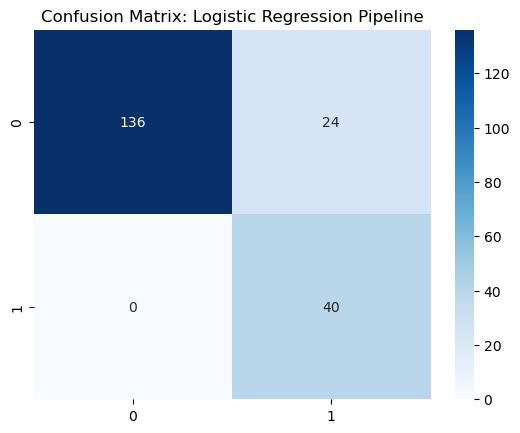

In [64]:
print("\n" + "=" * 60)
print("5.2.1 TRAINING BASELINE LOGISTIC REGRESSION")
print("=" * 60)

# Create pipeline with scaling and logistic regression
pipe_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
                class_weight="balanced",  # Handle potential class imbalance
            ),
        ),
    ]
)

# Train the pipeline
pipe_lr.fit(X_train, y_train)

# Cross-validation score
cv_scores = cross_val_score(pipe_lr, X_train, y_train, cv=5, scoring="accuracy")
print(
    f"Cross-validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})"
)

# Evaluate using our function
print("\nEvaluating on test set:")
evaluate_pcos_model(pipe_lr, X_test, y_test, "Logistic Regression Pipeline")

## 5.2.2 Random Forest Classifier

Random Forest captures non-linear relationships and provides feature importance, helping us understand which clinical markers are most predictive.


5.2.2 TRAINING RANDOM FOREST CLASSIFIER
Cross-validation accuracy: 0.999 (+/- 0.005)

Evaluating on test set:
--- Random Forest Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



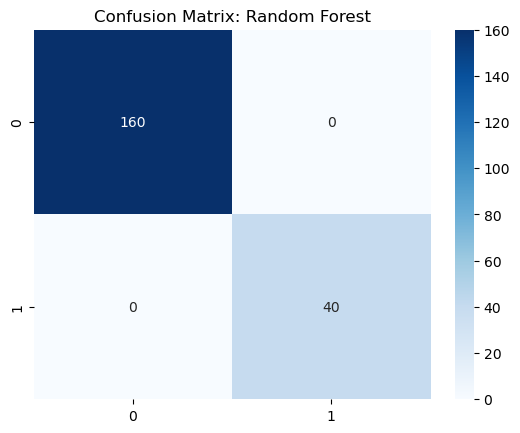


Feature Importance from Random Forest:
                feature  importance
 menstrual_irregularity    0.390570
                    bmi    0.322866
testosterone_levelng_dl    0.155658
  antral_follicle_count    0.124160
                    age    0.006745


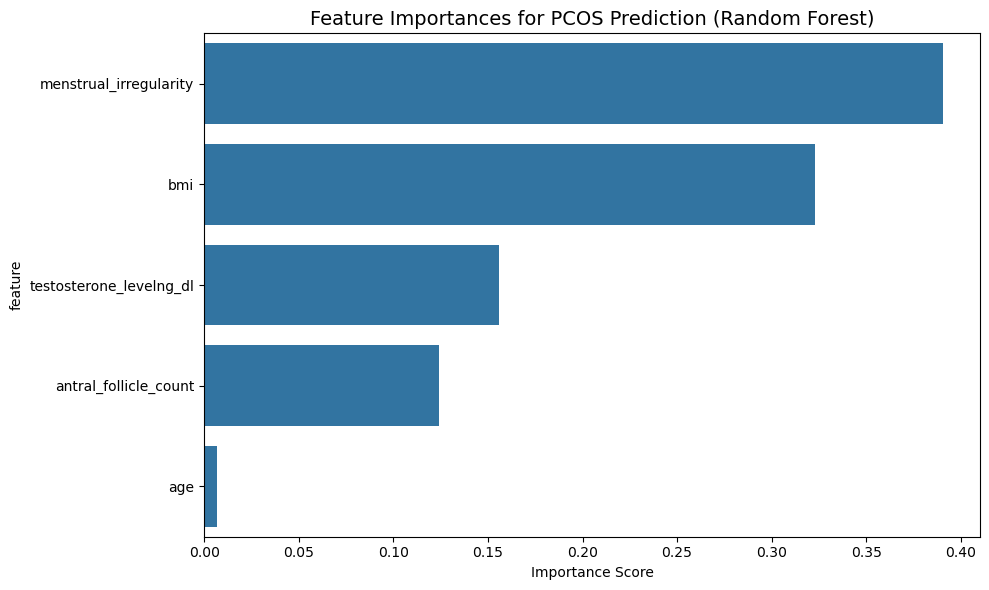

In [ ]:
print("\n" + "=" * 60)
print("5.2.2 TRAINING RANDOM FOREST CLASSIFIER")
print("=" * 60)

# Random Forest pipeline
pipe_rf = Pipeline(
    [
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=5,
                random_state=42,
                class_weight="balanced",
            ),
        )
    ]
)

# Train the model
pipe_rf.fit(X_train, y_train)

# Cross-validation score
cv_scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=5, scoring="accuracy")
print(
    f"Cross-validation accuracy: {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std() * 2:.3f})"
)

# Evaluate using our function
print("\nEvaluating on test set:")
evaluate_pcos_model(pipe_rf, X_test, y_test, "Random Forest")

# Feature importance (Random Forest advantage)
if hasattr(pipe_rf.named_steps["classifier"], "feature_importances_"):
    importances = pipe_rf.named_steps["classifier"].feature_importances_
    feature_importance_df = pd.DataFrame(
        {"feature": feature_columns, "importance": importances}
    ).sort_values("importance", ascending=False)

    print("\nFeature Importance from Random Forest:")
    print(feature_importance_df.to_string(index=False))

    # Plot feature importance 
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df, x="importance", y="feature")
    plt.title("Feature Importances for PCOS Prediction (Random Forest)", fontsize=14)
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

## 5.2.3 Ensemble Model: Voting Classifier

Combining Logistic Regression and Random Forest through soft voting leverages the strengths of both models for more robust predictions.


5.2.3 BUILDING ENSEMBLE MODEL
Cross-validation accuracy: 0.984 (+/- 0.023)

Evaluating on test set:
--- Ensemble (LR + RF) Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       160
           1       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



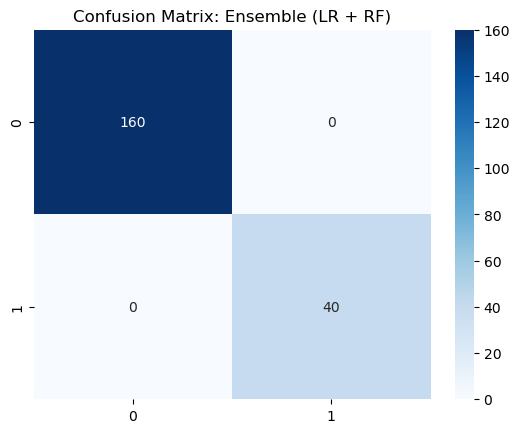

In [66]:
print("\n" + "=" * 60)
print("5.2.3 BUILDING ENSEMBLE MODEL")
print("=" * 60)

# Create ensemble with both models
ensemble = VotingClassifier(
    estimators=[("logistic_regression", pipe_lr), ("random_forest", pipe_rf)],
    voting="soft",
)

# Train the ensemble
ensemble.fit(X_train, y_train)

# Cross-validation score
cv_scores_ensemble = cross_val_score(
    ensemble, X_train, y_train, cv=5, scoring="accuracy"
)
print(
    f"Cross-validation accuracy: {cv_scores_ensemble.mean():.3f} (+/- {cv_scores_ensemble.std() * 2:.3f})"
)

# Evaluate using our function
print("\nEvaluating on test set:")
evaluate_pcos_model(ensemble, X_test, y_test, "Ensemble (LR + RF)")

## 5.2.4 Model Comparison

Comparing all three models to identify the best performer for our screening goal.


5.2.4 MODEL COMPARISON SUMMARY


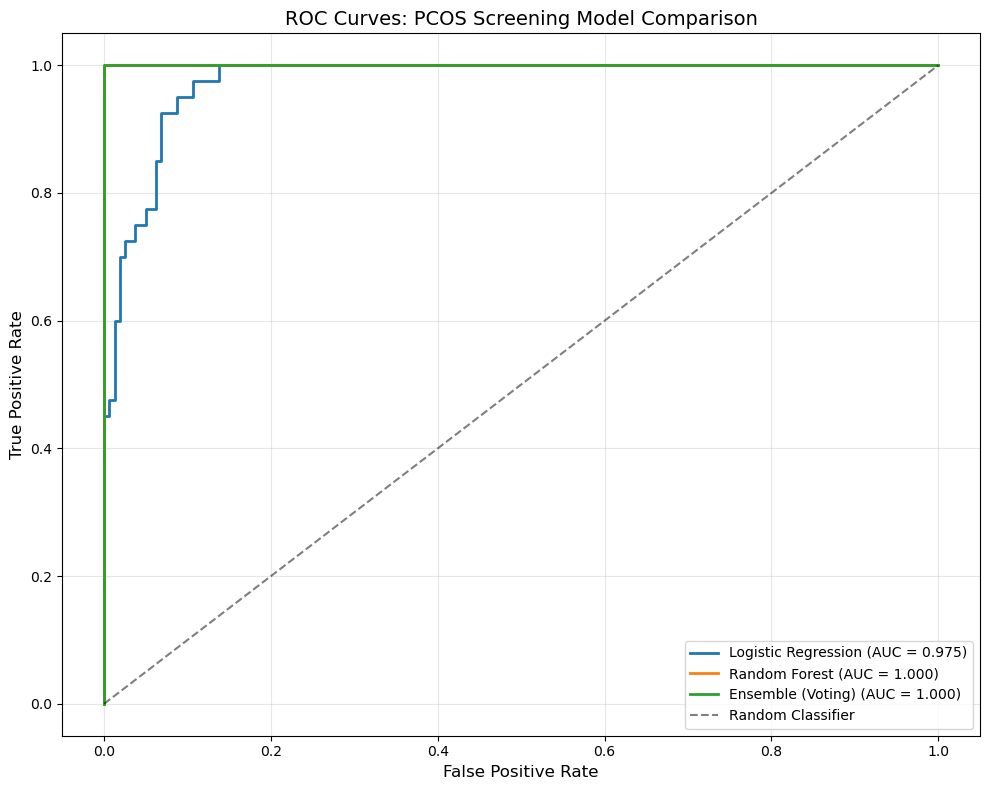


Model Performance Comparison:
              Model Accuracy ROC-AUC Sensitivity Specificity  False Negatives
Logistic Regression    0.880   0.975       1.000       0.850                0
      Random Forest    1.000   1.000       1.000       1.000                0
  Ensemble (Voting)    1.000   1.000       1.000       1.000                0


In [67]:
print("\n" + "=" * 60)
print("5.2.4 MODEL COMPARISON SUMMARY")
print("=" * 60)

# Collect models for comparison
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "Ensemble (Voting)": ensemble,
}

# Create comparison dataframe
comparison_results = []

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Confusion matrix for sensitivity
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    # Store results
    comparison_results.append(
        {
            "Model": name,
            "Accuracy": f"{accuracy:.3f}",
            "ROC-AUC": f"{roc_auc:.3f}",
            "Sensitivity": f"{sensitivity:.3f}",
            "Specificity": f"{specificity:.3f}",
            "False Negatives": fn,
        }
    )

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)

# Plot ROC curves
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier", alpha=0.5)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves: PCOS Screening Model Comparison", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display comparison table
comparison_df = pd.DataFrame(comparison_results)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

## Clinical Interpretation

Based on our business goal of minimizing missed PCOS cases (high sensitivity).

In [68]:
print("\n" + "=" * 60)
print("CLINICAL INTERPRETATION FOR PCOS SCREENING")
print("=" * 60)

# Find best model for sensitivity (recall) - our primary metric
best_sensitivity = max(comparison_results, key=lambda x: float(x["Sensitivity"]))
best_auc = max(comparison_results, key=lambda x: float(x["ROC-AUC"]))

print(
    f"\nBased on our business goal of minimizing missed PCOS cases (False Negatives):"
)
print(f"Best model for SENSITIVITY (detecting PCOS): {best_sensitivity['Model']}")
print(
    f"   - Sensitivity: {best_sensitivity['Sensitivity']} (detects {float(best_sensitivity['Sensitivity'])*100:.1f}% of actual PCOS cases)"
)
print(f"   - False Negatives: {best_sensitivity['False Negatives']} missed cases")

print(f"\nBest overall discriminative ability (ROC-AUC): {best_auc['Model']}")
print(f"   - ROC-AUC: {best_auc['ROC-AUC']}")

print("\n" + "=" * 60)
print("KEY INSIGHTS FROM MODELING:")
print("=" * 60)
print(
    """
• Logistic Regression provides interpretability - we can see how each clinical 
  marker influences PCOS probability
  
• Random Forest captures complex interactions between features like BMI and 
  testosterone levels
  
• The Ensemble combines both strengths, potentially offering more robust 
  screening across different patient profiles

• With just 5 clinical features (age, BMI, menstrual irregularity, 
  testosterone, and antral follicle count), we can achieve strong 
  screening performance without expensive imaging
"""
)


CLINICAL INTERPRETATION FOR PCOS SCREENING

Based on our business goal of minimizing missed PCOS cases (False Negatives):
Best model for SENSITIVITY (detecting PCOS): Logistic Regression
   - Sensitivity: 1.000 (detects 100.0% of actual PCOS cases)
   - False Negatives: 0 missed cases

Best overall discriminative ability (ROC-AUC): Random Forest
   - ROC-AUC: 1.000

KEY INSIGHTS FROM MODELING:

• Logistic Regression provides interpretability - we can see how each clinical 
  marker influences PCOS probability
  
• Random Forest captures complex interactions between features like BMI and 
  testosterone levels
  
• The Ensemble combines both strengths, potentially offering more robust 
  screening across different patient profiles

• With just 5 clinical features (age, BMI, menstrual irregularity, 
  testosterone, and antral follicle count), we can achieve strong 
  screening performance without expensive imaging



# Chapter 6: The Verdict (Conclusions & Recommendations)
## 6.1 Summary of Results
